In [31]:
import pandas as pd
import numpy as np

In [32]:
forest = pd.read_excel("Forest_cleaned.xlsx", sheet_name=None)
grassland = pd.read_excel("Grassland_cleaned.xlsx", sheet_name=None)

In [33]:
forest_df = pd.concat(forest.values(), ignore_index=True)
grass_df = pd.concat(grassland.values(), ignore_index=True)

In [34]:
df = pd.concat([forest_df, grass_df], ignore_index=True)

In [35]:
df.head()


,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Visit,Interval_Length,ID_Method,...,Flyover_Observed,Sex,Common_Name,Scientific_Name,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,0-2.5 min,Singing,...,False,Undetermined,Eastern Towhee,Pipilo erythrophthalmus,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
1,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,0-2.5 min,Calling,...,False,unknown,White-breasted Nuthatch,Sitta carolinensis,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
2,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,2.5 - 5 min,Calling,...,False,unknown,Red-bellied Woodpecker,Melanerpes carolinus,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
3,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,2.5 - 5 min,Singing,...,False,unknown,Orchard Oriole,Icterus spurius,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
4,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,2.5 - 5 min,Visualization,...,False,unknown,Northern Mockingbird,Mimus polyglottos,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False


In [36]:
df.shape


(15372, 21)

In [37]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15372 entries, 0 to 15371
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Site_Name              8546 non-null   object        
 1   Plot_Name              15372 non-null  object        
 2   Location_Type          15372 non-null  object        
 3   Year                   15372 non-null  int64         
 4   Date                   15372 non-null  datetime64[ns]
 5   Start_Time             15372 non-null  object        
 6   End_Time               15372 non-null  object        
 7   Visit                  15372 non-null  int64         
 8   Interval_Length        15372 non-null  object        
 9   ID_Method              15372 non-null  object        
 10  Distance               15372 non-null  object        
 11  Flyover_Observed       15372 non-null  bool          
 12  Sex                    15372 non-null  object        
 13  C

In [38]:
df.describe()


,Year,Date,Visit,Temperature,Humidity
count,15372.0,15372,15372.000000,15372.000000,15372.000000
mean,2018.0,2018-06-13 17:45:11.943794176,1.690997,22.493826,74.159335
min,2018.0,2018-05-07 00:00:00,1.000000,11.000000,7.300000
25%,2018.0,2018-05-24 00:00:00,1.000000,19.700000,68.000000
50%,2018.0,2018-06-14 00:00:00,2.000000,22.200000,76.600000
75%,2018.0,2018-07-03 00:00:00,2.000000,25.000000,83.400000
max,2018.0,2018-07-19 00:00:00,3.000000,37.300000,98.800000
std,0.0,NaN,0.698253,4.193138,12.168509


In [39]:
df.isnull().sum().sort_values(ascending=False)

Site_Name                6826
Flyover_Observed            0
Disturbance                 0
Wind                        0
Sky                         0
Humidity                    0
Temperature                 0
Scientific_Name             0
Common_Name                 0
Sex                         0
Distance                    0
Plot_Name                   0
ID_Method                   0
Interval_Length             0
Visit                       0
End_Time                    0
Start_Time                  0
Date                        0
Year                        0
Location_Type               0
Initial_Three_Min_Cnt       0
dtype: int64

In [40]:
df = df.dropna(subset=['Common_Name', 'Location_Type'])
df = df.dropna(axis=1, thresh=5)
df.head()

,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Visit,Interval_Length,ID_Method,...,Flyover_Observed,Sex,Common_Name,Scientific_Name,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt
0,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,0-2.5 min,Singing,...,False,Undetermined,Eastern Towhee,Pipilo erythrophthalmus,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
1,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,0-2.5 min,Calling,...,False,unknown,White-breasted Nuthatch,Sitta carolinensis,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True
2,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,2.5 - 5 min,Calling,...,False,unknown,Red-bellied Woodpecker,Melanerpes carolinus,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
3,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,2.5 - 5 min,Singing,...,False,unknown,Orchard Oriole,Icterus spurius,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False
4,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,1,2.5 - 5 min,Visualization,...,False,unknown,Northern Mockingbird,Mimus polyglottos,19.9,79.4,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False


In [41]:
# Habitat Distribution
df['Location_Type'].value_counts()

Location_Type
Forest       8546
Grassland    6826
Name: count, dtype: int64

In [42]:
# Most Observed Species
df['Common_Name'].value_counts().head(10)

Common_Name
Northern Cardinal          1125
Carolina Wren               993
Red-eyed Vireo              738
Eastern Tufted Titmouse     720
Indigo Bunting              611
Eastern Wood-Pewee          574
Field Sparrow               492
Red-bellied Woodpecker      489
American Robin              470
Acadian Flycatcher          462
Name: count, dtype: int64

In [43]:
# Which habitat has more diversity?
df.groupby('Location_Type')['Common_Name'].nunique()

Location_Type
Forest       108
Grassland    107
Name: Common_Name, dtype: int64

In [44]:
# Environmental conditions difference
df.groupby('Location_Type')[['Temperature','Humidity']].mean()

,Temperature,Humidity
Location_Type,,
Forest,21.871507,77.757033
Grassland,23.272956,69.655098


In [45]:
# Bird Activity by Time
df['hour'] = df['Start_Time'].apply(lambda x: x.hour)

df.groupby('hour')['Common_Name'].count()

hour
5     1288
6     3837
7     4014
8     3196
9     2016
10    1021
Name: Common_Name, dtype: int64

In [46]:
# Which species prefer which habitat
pd.crosstab(df['Common_Name'], df['Location_Type'])

Location_Type,Forest,Grassland
Common_Name,,
Acadian Flycatcher,436,26
American Crow,142,137
American Goldfinch,147,310
American Kestrel,0,7
American Redstart,25,7
...,...,...
Yellow-billed Cuckoo,133,43
Yellow-breasted Chat,4,5
Yellow-rumped Warbler,3,0


In [47]:
# Bird movement patterns
df['Flyover_Observed'].value_counts()

Flyover_Observed
False    14683
True       689
Name: count, dtype: int64

In [48]:
df['Distance'].value_counts()

Distance
50 - 100 Meters    7774
<= 50 Meters       6909
unknown             687
unknown               2
Name: count, dtype: int64

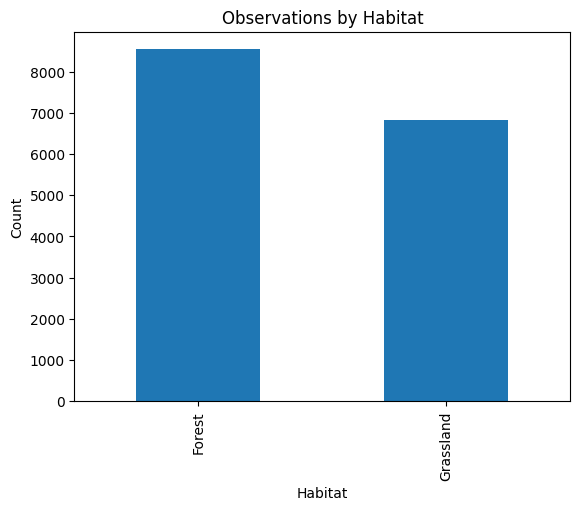

In [49]:
# Which habitat has more observations
import matplotlib.pyplot as plt

df['Location_Type'].value_counts().plot(kind='bar')
plt.title("Observations by Habitat")
plt.xlabel("Habitat")
plt.ylabel("Count")
plt.show()

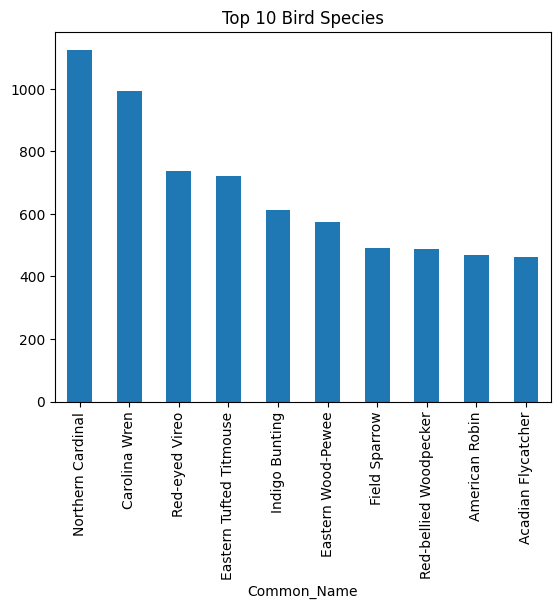

In [50]:
top_species = df['Common_Name'].value_counts().head(10)

top_species.plot(kind='bar')
plt.title("Top 10 Bird Species")
plt.show()

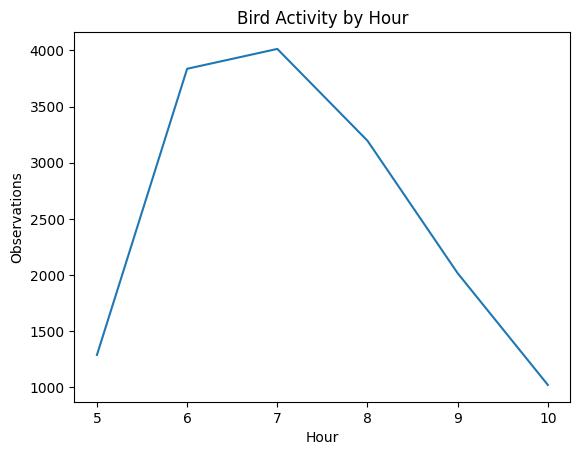

In [51]:
df.groupby('hour')['Common_Name'].count().plot()
plt.title("Bird Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Observations")
plt.show()

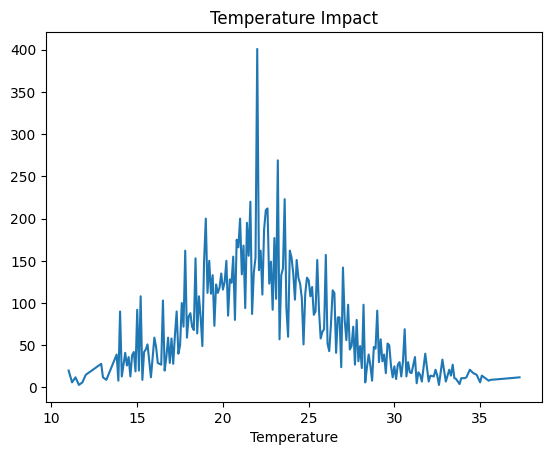

In [52]:
df.groupby('Temperature')['Common_Name'].count().plot()
plt.title("Temperature Impact")
plt.show()

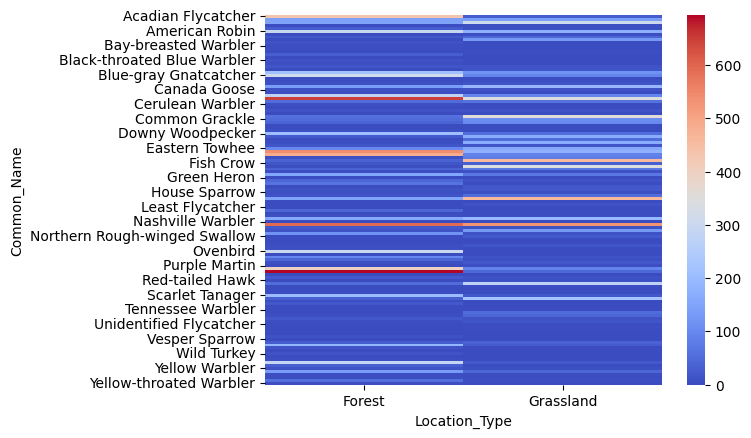

In [53]:
import seaborn as sns

pivot = pd.crosstab(df['Common_Name'], df['Location_Type'])

sns.heatmap(pivot, cmap='coolwarm')
plt.show()